In [1]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [2]:
df = pd.read_csv('gemini.csv')

In [4]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [5]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        criterion=criterion,
        random_state=1
    )

    score = cross_val_score(model, X_train, y_train, cv=5).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

c:\Users\e.i.chapaev\.conda\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-16 17:56:35,829] A new study created in memory with name: no-name-d68354a5-69b3-4594-86d5-b411d4d0c0b2
[I 2026-04-16 17:56:35,857] Trial 0 finished with value: 0.5805555555555555 and parameters: {'max_depth': 12, 'min_samples_leaf': 16, 'min_samples_split': 18, 'criterion': 'gini'}. Best is trial 0 with value: 0.5805555555555555.
[I 2026-04-16 17:56:35,871] Trial 1 finished with value: 0.9277777777777778 and parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 11, 'criterion': 'gini'}. Best is trial 1 with value: 0.9277777777777778.
[I 2026-04-16 17:56:35,901] Trial 2 finished with value: 0.9277777777777778 and parameters: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 4, 'criterion'

Best params: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 10, 'criterion': 'entropy'}
Best score: 0.95


In [4]:
model = CatBoostClassifier(
    iterations=500,           # для маленьких данных лучше меньше итераций + раннее стоппинг
    learning_rate=0.03,
    depth=6,
    auto_class_weights='Balanced', # Решает проблему дисбаланса 0 и 1
    eval_metric='F1',          # Оптимизируем под дисбаланс, а не под точность
    verbose=100,               # Выводить лог каждые 100 шагов
    random_seed=42
)

# 3. Обучение с защитой от переобучения
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50   # Остановится, если F1 перестанет расти
)

# 4. Получение вероятностей
y_proba = model.predict_proba(X_test)[:, 1]

# 5. Предсказание классов
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

0:	learn: 0.9743590	test: 0.4615385	best: 0.4615385 (0)	total: 89.7ms	remaining: 44.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8888888889
bestIteration = 3

Shrink model to first 4 iterations.
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89         8
         1.0       1.00      0.80      0.89        10

    accuracy                           0.89        18
   macro avg       0.90      0.90      0.89        18
weighted avg       0.91      0.89      0.89        18



In [5]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 88.89%


Accuracy:0.889
Precision:1.000
Recall:  0.800
F1-score: 0.889

Confusion Matrix:
 [[8 0]
 [2 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      1.00      0.89         8
         1.0       1.00      0.80      0.89        10

    accuracy                           0.89        18
   macro avg       0.90      0.90      0.89        18
weighted avg       0.91      0.89      0.89        18

0:	learn: 1.0000000	total: 782us	remaining: 391ms
100:	learn: 1.0000000	total: 65.5ms	remaining: 259ms
200:	learn: 1.0000000	total: 128ms	remaining: 190ms
300:	learn: 1.0000000	total: 181ms	remaining: 120ms
400:	learn: 1.0000000	total: 236ms	remaining: 58.3ms
499:	learn: 1.0000000	total: 289ms	remaining: 0us
0:	learn: 1.0000000	total: 852us	remaining: 426ms
100:	learn: 1.0000000	total: 69ms	remaining: 273ms
200:	learn: 1.0000000	total: 138ms	remaining: 206ms
300:	learn: 1.0000000	total: 208ms	remaining: 138ms
400:	learn: 1.0000000	total: 277ms	r

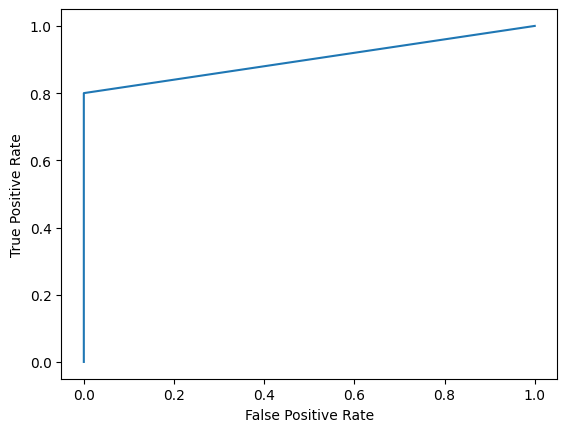

In [6]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

In [7]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.889
Precision:1.000
Recall:  0.800
F1-score: 0.889
ROC-AUC:0.950

Confusion Matrix:
 [[8 0]
 [2 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      1.00      0.89         8
         1.0       1.00      0.80      0.89        10

    accuracy                           0.89        18
   macro avg       0.90      0.90      0.89        18
weighted avg       0.91      0.89      0.89        18



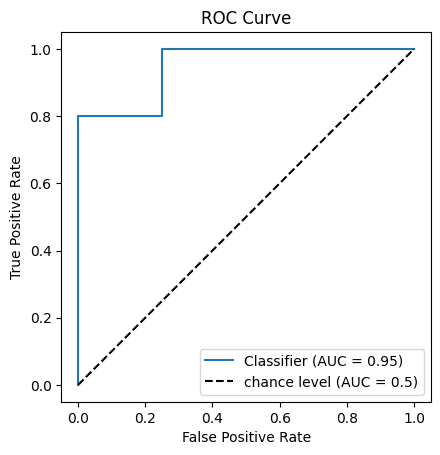

In [8]:
RocCurveDisplay.from_predictions(y_test, y_proba)

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

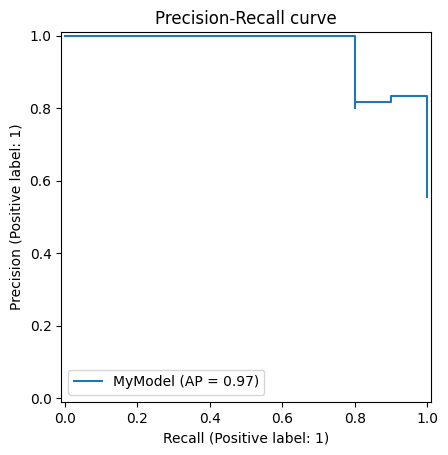

In [9]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()